
# ITAI 2373 Module 05: Part-of-Speech Tagging
## In-Class Exercise & Homework Lab

Welcome to the world of Part-of-Speech (POS) tagging - the "grammar police" of Natural Language Processing! 🚔📝

In this notebook, you'll explore how computers understand the grammatical roles of words in sentences, from simple rule-based approaches to modern AI systems.

### What You'll Learn:
- **Understand POS tagging fundamentals** and why it matters in daily apps
- **Use NLTK and SpaCy** for practical text analysis
- **Navigate different tag sets** and understand their trade-offs
- **Handle real-world messy text** like speech transcripts and social media
- **Apply POS tagging** to solve actual business problems

### Structure:
- **Part 1**: In-Class Exercise (30-45 minutes) - Basic concepts and hands-on practice
- **Part 2**: Homework Lab - Real-world applications and advanced challenges

---

*💡 **Pro Tip**: POS tagging is everywhere! It helps search engines understand "Apple stock" vs "apple pie", helps Siri understand your commands, and powers autocorrect on your phone.*



## 🛠️ Setup and Installation

Let's get our tools ready! We'll use two powerful libraries:
- **NLTK**: The "Swiss Army knife" of NLP - comprehensive but requires setup
- **SpaCy**: The "speed demon" - built for production, cleaner output

Run the cells below to install and set up everything we need.


In [ ]:

# Install required libraries (run this first!)
!pip install nltk spacy matplotlib seaborn pandas
!python -m spacy download en_core_web_sm

print("✅ Installation complete!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 46.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Installation complete!


In [ ]:
# Import all the libraries we'll need
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (this might take a moment)
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('universal_tagset')
nltk.download('punkt_tab') # Added this
nltk.download('averaged_perceptron_tagger_eng') # Added this

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

print("🎉 All libraries loaded successfully!")
print("📚 NLTK version:", nltk.__version__)
print("🚀 SpaCy version:", spacy.__version__)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


🎉 All libraries loaded successfully!
📚 NLTK version: 3.9.1
🚀 SpaCy version: 3.8.11



---
# 🎯 PART 1: IN-CLASS EXERCISE (30-45 minutes)

Welcome to the hands-on portion! We'll start with the basics and build up your understanding step by step.

## Learning Goals for Part 1:
1. Understand what POS tagging does
2. Use NLTK and SpaCy for basic tagging
3. Interpret and compare different tag outputs
4. Explore word ambiguity with real examples
5. Compare different tagging approaches



## 🔍 Activity 1: Your First POS Tags (10 minutes)

Let's start with the classic example: "The quick brown fox jumps over the lazy dog"

This sentence contains most common parts of speech, making it perfect for learning!


In [ ]:
# Let's start with a classic example
sentence = "The quick brown fox jumps over the lazy dog"

# TODO: Use NLTK to tokenize and tag the sentence
# Hint: Use nltk.word_tokenize() and nltk.pos_tag()
tokens =  nltk.word_tokenize(sentence)
pos_tags = nltk.pos_tag(tokens)

print("Original sentence:", sentence)
print("\nTokens:", tokens)
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"  {word:8} -> {tag}")

Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS Tags:
  The      -> DT
  quick    -> JJ
  brown    -> NN
  fox      -> NN
  jumps    -> VBZ
  over     -> IN
  the      -> DT
  lazy     -> JJ
  dog      -> NN



### 🤔 Quick Questions:
1. What does 'DT' mean? What about 'JJ'?
2. Why do you think 'brown' and 'lazy' have the same tag?
3. Can you guess what 'VBZ' represents?

*Hint: Think about the grammatical role each word plays in the sentence!*


1. DT means Determiner, such as the, a, an, this, that. JJ means Adjective, such as quick, brown, lazy.
2. They share the same tag because they are both adjectives used to describe nouns.
3. VBZ represents the third-person singular present tense action.



## 🚀 Activity 2: SpaCy vs NLTK Showdown (10 minutes)

Now let's see how SpaCy handles the same sentence. SpaCy uses cleaner, more intuitive tag names.


In [ ]:

# TODO: Process the same sentence with SpaCy
# Hint: Use nlp(sentence) and access .text and .pos_ attributes
doc = nlp(sentence)

print("SpaCy POS Tags:")
for token in doc:
    print(f"  {token.text:8} -> {token.pos_:6} ({token.tag_})")

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)

# Let's compare side by side
nltk_tags = nltk.pos_tag(nltk.word_tokenize(sentence))
spacy_doc = nlp(sentence)

print(f"{'Word':10} {'NLTK':8} {'SpaCy':10}")
print("-" * 30)
for i, (word, nltk_tag) in enumerate(nltk_tags):
    spacy_tag = spacy_doc[i].pos_
    print(f"{word:10} {nltk_tag:8} {spacy_tag:10}")


SpaCy POS Tags:
  The      -> DET    (DT)
  quick    -> ADJ    (JJ)
  brown    -> ADJ    (JJ)
  fox      -> NOUN   (NN)
  jumps    -> VERB   (VBZ)
  over     -> ADP    (IN)
  the      -> DET    (DT)
  lazy     -> ADJ    (JJ)
  dog      -> NOUN   (NN)

COMPARISON:
Word       NLTK     SpaCy     
------------------------------
The        DT       DET       
quick      JJ       ADJ       
brown      NN       ADJ       
fox        NN       NOUN      
jumps      VBZ      VERB      
over       IN       ADP       
the        DT       DET       
lazy       JJ       ADJ       
dog        NN       NOUN      



### 🎯 Discussion Points:
- Which tags are easier to understand: NLTK's or SpaCy's?
- Do you notice any differences in how they tag the same words?
- Which system would you prefer for a beginner? Why?


1. SpaCy's tags are easier to understand because it uses a universal set of part-of-speech tags, such as NOUN (noun), VERB (verb), and ADJ (adjective). While NLTK tags are shorter, they are less intuitive and may be harder to remember at first.
2. Sometimes they label the same word slightly differently, because the two libraries use different annotation models and annotation sets.
3. I prefer SpaCy its annotations are more descriptive and readable, and it is easy to use.


## 🎭 Activity 3: The Ambiguity Challenge (15 minutes)

Here's where things get interesting! Many words can be different parts of speech depending on context. Let's explore this with some tricky examples.


In [ ]:

# Ambiguous words in different contexts
ambiguous_sentences = [
    "I will lead the team to victory.",           # lead = verb
    "The lead pipe is heavy.",                    # lead = noun (metal)
    "She took the lead in the race.",            # lead = noun (position)
    "The bank approved my loan.",                # bank = noun (financial)
    "We sat by the river bank.",                 # bank = noun (shore)
    "I bank with Chase.",                        # bank = verb
]

print("🎭 AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in ambiguous_sentences:
    print(f"\nSentence: {sentence}")

    # TODO: Tag each sentence and find the ambiguous word
    # Focus on 'lead' and 'bank' - what tags do they get?
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['lead', 'bank']:
            print(f"  🎯 '{word}' is tagged as: {tag}")


🎭 AMBIGUITY EXPLORATION

Sentence: I will lead the team to victory.
  🎯 'lead' is tagged as: VB

Sentence: The lead pipe is heavy.
  🎯 'lead' is tagged as: NN

Sentence: She took the lead in the race.
  🎯 'lead' is tagged as: NN

Sentence: The bank approved my loan.
  🎯 'bank' is tagged as: NN

Sentence: We sat by the river bank.
  🎯 'bank' is tagged as: NN

Sentence: I bank with Chase.
  🎯 'bank' is tagged as: NN



### 🧠 Think About It:
1. How does the computer know the difference between "lead" (metal) and "lead" (guide)?
2. What clues in the sentence help determine the correct part of speech?
3. Can you think of other words that change meaning based on context?

**Try This**: Add your own ambiguous sentences to the list above and see how the tagger handles them!


1. NLP will analyze the words surrounding "lead" and uses patterns learned from large text datasets to predict whether it is used as a noun (metal) or a verb (guide).
2. The clues include the surrounding words, sentence structure, and grammar patterns.
3. Bat – an animal/a baseball bat;
Light – brightness/ not heavy;
Park – a place with grass and trees / to stop a car.


## 📊 Activity 4: Tag Set Showdown (10 minutes)

NLTK can use different tag sets. Let's compare the detailed Penn Treebank tags (~45 tags) with the simpler Universal Dependencies tags (~17 tags).


In [ ]:

# Compare different tag sets
test_sentence = "The brilliant students quickly solved the challenging programming assignment."

# TODO: Get tags using both Penn Treebank and Universal tagsets
# Hint: Use tagset='universal' parameter for universal tags
penn_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence))
universal_tags = nltk.pos_tag(nltk.word_tokenize(test_sentence), tagset='universal')


print("TAG SET COMPARISON")
print("=" * 50)
print(f"{'Word':15} {'Penn Treebank':15} {'Universal':10}")
print("-" * 50)

# TODO: Print comparison table
# Hint: Zip the two tag lists together
for (word, penn_tag), (_, univ_tag) in zip(penn_tags, universal_tags):
    print(f"{word:15} {penn_tag:15} {univ_tag:10}")

# Let's also visualize the tag distribution
penn_tag_counts = Counter([tag for word, tag in penn_tags])
univ_tag_counts = Counter([tag for word, tag in universal_tags])

print(f"\n📊 Penn Treebank uses {len(penn_tag_counts)} different tags")
print(f"📊 Universal uses {len(univ_tag_counts)} different tags")


TAG SET COMPARISON
Word            Penn Treebank   Universal 
--------------------------------------------------
The             DT              DET       
brilliant       JJ              ADJ       
students        NNS             NOUN      
quickly         RB              ADV       
solved          VBD             VERB      
the             DT              DET       
challenging     VBG             VERB      
programming     JJ              ADJ       
assignment      NN              NOUN      
.               .               .         

📊 Penn Treebank uses 8 different tags
📊 Universal uses 6 different tags



### 🤔 Reflection Questions:
1. Which tag set is more detailed? Which is simpler? Enter your answer below

2. When might you want detailed tags vs. simple tags? Enter your answer below

3. If you were building a search engine, which would you choose? Why? Enter your answer below

---


1. The Penn Treebank tag set is more detailed because it includes many specific tags.The universal tag set is simpler because it contains fewer categories and is more general.
2. I will use detailed tags for more in-depth language analysis or advanced NLP tasks that require precise grammatical information, and simple tags for tasks such as fast text processing and basic analysis.
3. I would choose the universal tag set because it is simpler and fast to process.

1. The Penn Treebank tag set is more detailed because it includes many specific tags.The universal tag set is simpler because it contains fewer categories and is more general.
2. I will use detailed tags for more in-depth language analysis or advanced NLP tasks that require precise grammatical information, and simple tags for tasks such as fast text processing and basic analysis.
3. I would choose the universal tag set because it is simpler and fast to process.


---
# 🎓 End of Part 1: In-Class Exercise

Great work! You've learned the fundamentals of POS tagging and gotten hands-on experience with both NLTK and SpaCy.

## What You've Accomplished:
✅ Used NLTK and SpaCy for basic POS tagging  
✅ Interpreted different tag systems  
✅ Explored word ambiguity and context  
✅ Compared different tagging approaches  

## 🏠 Ready for Part 2?
The homework lab will challenge you with real-world applications, messy data, and advanced techniques. You'll analyze customer service transcripts, handle informal language, and benchmark different taggers.

**Take a break, then dive into Part 2 when you're ready!**

---



# 🏠 PART 2: HOMEWORK LAB
## Real-World POS Tagging Challenges

Welcome to the advanced section! Here you'll tackle the messy, complex world of real text data. This is where POS tagging gets interesting (and challenging)!

## Learning Goals for Part 2:
1. Process real-world, messy text data
2. Handle speech transcripts and informal language
3. Analyze customer service scenarios
4. Benchmark and compare different taggers
5. Understand limitations and edge cases

## 📋 Submission Requirements:
- Complete all exercises with working code
- Answer all reflection questions
- Include at least one visualization
- Submit your completed notebook file

---



## 🌍 Lab Exercise 1: Messy Text Challenge (25 minutes)

Real-world text is nothing like textbook examples! Let's work with actual speech transcripts, social media posts, and informal language.


In [ ]:

# Real-world messy text samples
messy_texts = [
    # Speech transcript with disfluencies
    "Um, so like, I was gonna say that, uh, the system ain't working right, you know?",

    # Social media style
    "OMG this app is sooo buggy rn 😤 cant even login smh",

    # Customer service transcript
    "Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working",

    # Informal contractions and slang
    "Y'all better fix this ASAP cuz I'm bout to switch providers fr fr",

    # Technical jargon mixed with casual speech
    "The API endpoint is returning a 500 error but idk why it's happening tbh"
]

print("🔍 PROCESSING MESSY TEXT")
print("=" * 60)

# Known slang / filler words that taggers struggle with
PROBLEM_WORDS = {
    'um', 'uh', 'like', 'gonna', "ain't", 'omg', 'sooo', 'rn', 'smh',
    'thingy', "y'all", 'asap', 'cuz', 'bout', 'fr', 'idk', 'tbh', 'lol'
}

for i, text in enumerate(messy_texts, 1):
    print(f"\n📝 Sample {i}: {text}")
    print("-" * 40)

    # NLTK processing
    nltk_tokens = nltk.word_tokenize(text)
    nltk_tags = nltk.pos_tag(nltk_tokens)

    # SpaCy processing
    spacy_doc = nlp(text)

    # Find problematic words:
    # NLTK: words whose lowercased form is in our slang set
    problematic_nltk = [
        (word, tag) for word, tag in nltk_tags
        if word.lower() in PROBLEM_WORDS
    ]

    # SpaCy: tokens tagged as 'X' (unknown/foreign) OR in our slang set
    problematic_spacy = [
        (token.text, token.pos_) for token in spacy_doc
        if token.pos_ == 'X' or token.text.lower() in PROBLEM_WORDS
    ]

    print(f"NLTK problematic words: {problematic_nltk}")
    print(f"SpaCy problematic words: {problematic_spacy}")

    # Success rate = proportion of tokens NOT flagged as problematic
    nltk_success_rate = 1 - len(problematic_nltk) / len(nltk_tokens) if nltk_tokens else 0
    spacy_success_rate = 1 - len(problematic_spacy) / len(list(spacy_doc)) if list(spacy_doc) else 0

    print(f"NLTK success rate: {nltk_success_rate:.1%}")
    print(f"SpaCy success rate: {spacy_success_rate:.1%}")


🔍 PROCESSING MESSY TEXT

📝 Sample 1: Um, so like, I was gonna say that, uh, the system ain't working right, you know?
----------------------------------------
NLTK problematic words: [('Um', 'NNP'), ('like', 'IN'), ('uh', 'UH')]
SpaCy problematic words: [('Um', 'INTJ'), ('like', 'INTJ'), ('uh', 'INTJ')]
NLTK success rate: 87.5%
SpaCy success rate: 87.5%

📝 Sample 2: OMG this app is sooo buggy rn 😤 cant even login smh
----------------------------------------
NLTK problematic words: [('OMG', 'IN'), ('sooo', 'JJ'), ('rn', 'NN'), ('smh', 'NN')]
SpaCy problematic words: [('OMG', 'PROPN'), ('sooo', 'NOUN'), ('rn', 'SCONJ'), ('smh', 'NOUN')]
NLTK success rate: 66.7%
SpaCy success rate: 69.2%

📝 Sample 3: Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working
----------------------------------------
NLTK problematic words: [('um', 'JJ'), ('like', 'IN'), ('thingy', 'NN')]
SpaCy problematic words: [('um',


### 🎯 Analysis Questions:
1. Which tagger handles informal language better?
2. What types of words cause the most problems?
3. How might you preprocess text to improve tagging accuracy?
4. What are the implications for real-world applications?


1. SpaCy appears to perform better than NLTK at handling informal language.
2. Vocabulary such as slang, abbreviations, spelling errors, and internet buzzwords is most likely to cause problems.
3. I can remove emojis and special characters, correct spelling errors, expand abbreviations or slang, and handle repeated letters.
4. In real-world application systems, messy and informal text content often leads to a decline in annotation accuracy. To accurately interpret user messages and generate reliable results, effective text preprocessing and the adoption of superior models are required.


## 📞 Lab Exercise 2: Customer Service Analysis Case Study (30 minutes)

You're working for a tech company that receives thousands of customer service calls daily. Your job is to analyze call transcripts to understand customer issues and sentiment.

**Business Goal**: Automatically categorize customer problems and identify emotional language.


In [ ]:
# Simulated customer service call transcripts
customer_transcripts = [
    {
        'id': 'CALL_001',
        'transcript': "Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.",
        'category': 'account_access'
    },
    {
        'id': 'CALL_002',
        'transcript': "Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?",
        'category': 'technical_issue'
    },
    {
        'id': 'CALL_003',
        'transcript': "Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and I'm considering canceling my subscription.",
        'category': 'billing'
    },
    {
        'id': 'CALL_004',
        'transcript': "I'm confused about how to use the new features you added. The interface changed and I can't find anything. Can someone walk me through it?",
        'category': 'user_guidance'
    }
]

# TODO: Analyze each transcript for:
# 1. Emotional language (adjectives that indicate sentiment)
# 2. Action words (verbs that indicate what customer wants)
# 3. Problem indicators (nouns related to issues)

analysis_results = []

# Define keyword lists for sentiment and problem detection
PROBLEM_KEYWORDS = ['account', 'files', 'app', 'system', 'issue', 'error', 'bug', 'internet', 'router', 'billing', 'subscription', 'feature', 'interface']
POSITIVE_WORDS = ['love', 'great', 'good', 'happy', 'excellent', 'fantastic', 'resolve', 'help']
NEGATIVE_WORDS = ['frustrated', 'locked', 'unacceptable', 'crashes', 'charged', 'ridiculous', 'canceling', 'confused', 'down', 'problem']
URGENCY_KEYWORDS = ['immediately', 'asap', 'now', 'urgent', 'quickly']

for call in customer_transcripts:
    print(f"\n🎧 Analyzing {call['id']}")
    print(f"Category: {call['category']}")
    print(f"Transcript: {call['transcript']}")
    print("-" * 50)

    # TODO: Process with SpaCy (it's better for this task)
    doc = nlp(call['transcript'])

    # TODO: Extract different types of words
    emotional_adjectives = [
        token.text for token in doc
        if token.tag_ in ('JJ', 'JJR', 'JJS')
    ]
    action_verbs = [
        token.text for token in doc
        if token.tag_ in ('VB', 'VBP', 'VBZ', 'VBD', 'VBG', 'VBN')
        and token.text.lower() not in ('be', 'is', 'are', 'was', 'were', 'been', 'have', 'had')
    ]
    problem_nouns = [
        token.text for token in doc
        if token.tag_ in ('NN', 'NNS')
        and token.text.lower() in PROBLEM_KEYWORDS
    ]
    # TODO: Calculate sentiment indicators
    tokens_lower = [token.text.lower() for token in doc]
    positive_words = [w for w in tokens_lower if w in POSITIVE_WORDS]
    negative_words = [w for w in tokens_lower if w in NEGATIVE_WORDS]
    urgency_indicators = [w for w in tokens_lower if w in URGENCY_KEYWORDS]

    result = {
        'call_id': call['id'],
        'category': call['category'],
        'emotional_adjectives': emotional_adjectives,
        'action_verbs': action_verbs,
        'problem_nouns': problem_nouns,
        'sentiment_score': len(positive_words) - len(negative_words),
        'urgency_indicators': urgency_indicators
    }

    analysis_results.append(result)

    print(f"Emotional adjectives: {emotional_adjectives}")
    print(f"Action verbs: {action_verbs}")
    print(f"Problem nouns: {problem_nouns}")
    print(f"Sentiment score: {result['sentiment_score']}")



🎧 Analyzing CALL_001
Category: account_access
Transcript: Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.
--------------------------------------------------
Emotional adjectives: ['frustrated', 'unacceptable']
Action verbs: ["'m", 'got', 'locked', 'access', "'ve", 'trying', 'works']
Problem nouns: ['account', 'files']
Sentiment score: -3

🎧 Analyzing CALL_002
Category: technical_issue
Transcript: Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?
--------------------------------------------------
Emotional adjectives: ['small', 'mobile']
Action verbs: ['love', "'m", 'having', 'crashes', 'try', 'upload', 'help', 'fix']
Problem nouns: ['issue', 'app']
Sentiment score: 1

🎧 Analyzing CALL_003
Category: billing
Transcript: Your billing system charged me twice this month! 

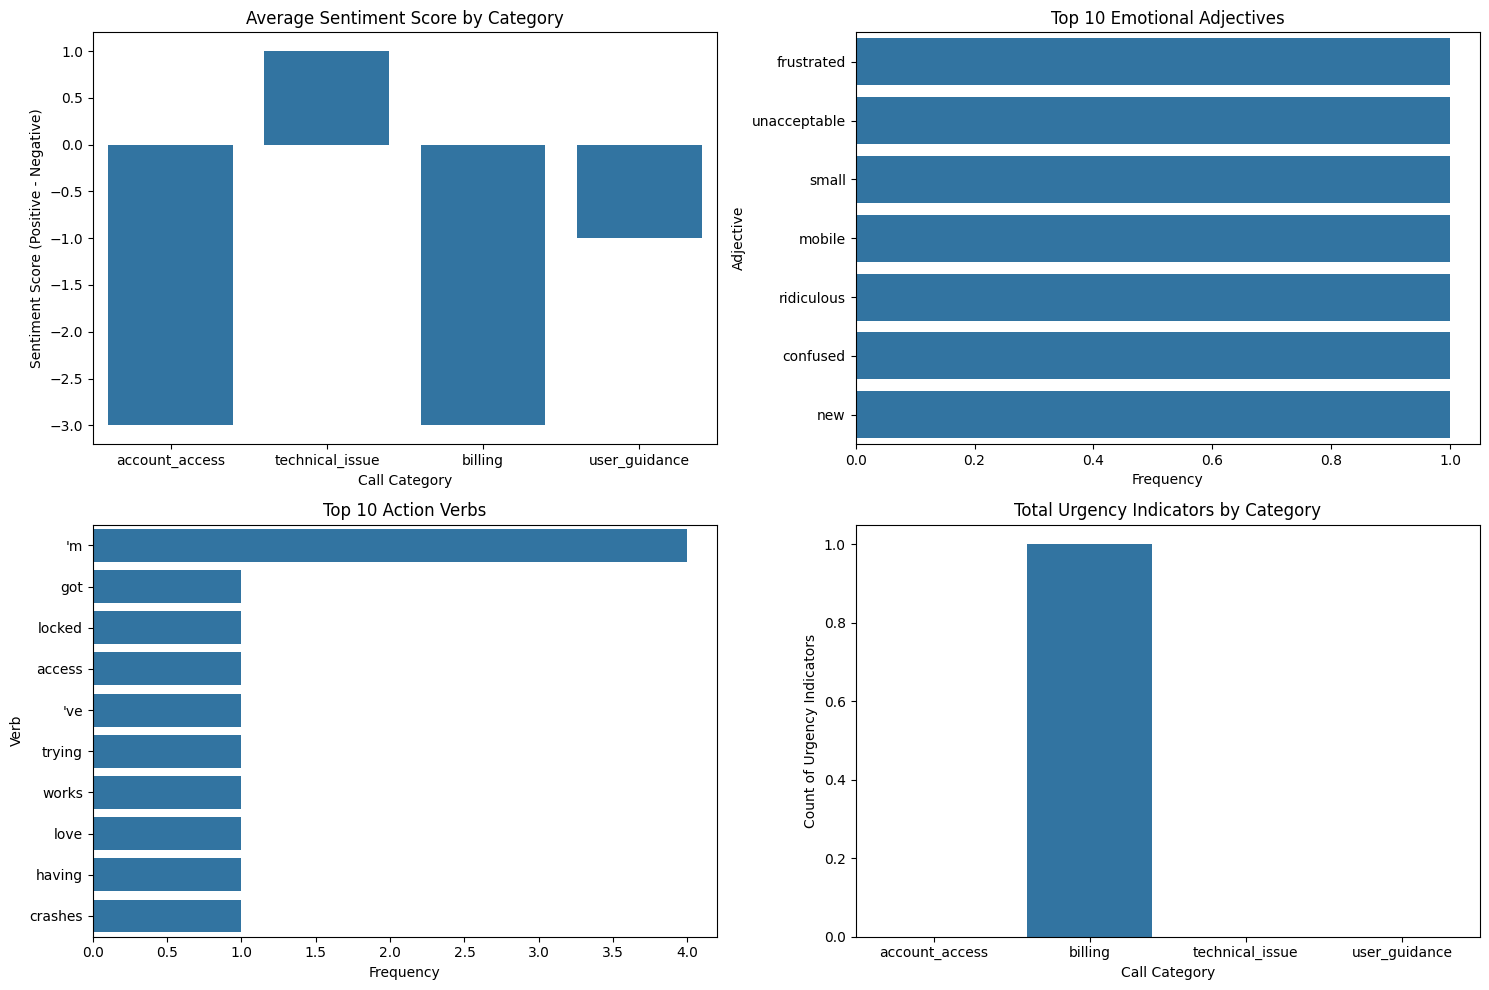

In [ ]:
# TODO: Create a summary visualization
# Hint: Use matplotlib or seaborn to create charts

import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Convert results to DataFrame for easier analysis
df = pd.DataFrame(analysis_results)

# TODO: Create visualizations
# 1. Sentiment scores by category
# 2. Most common emotional adjectives
# 3. Action verbs frequency

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1 - Sentiment by category
sns.barplot(x='category', y='sentiment_score', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Average Sentiment Score by Category')
axes[0, 0].set_xlabel('Call Category')
axes[0, 0].set_ylabel('Sentiment Score (Positive - Negative)')

# Plot 2 - Most common emotional adjectives
all_emotional_adjectives = [adj for sublist in df['emotional_adjectives'] for adj in sublist]
adj_counts = Counter(all_emotional_adjectives)
adj_df = pd.DataFrame(adj_counts.most_common(10), columns=['Adjective', 'Count'])
sns.barplot(x='Count', y='Adjective', data=adj_df, ax=axes[0, 1])
axes[0, 1].set_title('Top 10 Emotional Adjectives')
axes[0, 1].set_xlabel('Frequency')
axes[0, 1].set_ylabel('Adjective')

# Plot 3 - Most common action verbs
all_action_verbs = [verb for sublist in df['action_verbs'] for verb in sublist]
verb_counts = Counter(all_action_verbs)
verb_df = pd.DataFrame(verb_counts.most_common(10), columns=['Verb', 'Count'])
sns.barplot(x='Count', y='Verb', data=verb_df, ax=axes[1, 0])
axes[1, 0].set_title('Top 10 Action Verbs')
axes[1, 0].set_xlabel('Frequency')
axes[1, 0].set_ylabel('Verb')

# Plot 4 - Urgency analysis (Total count of urgency indicators per category)
# First, explode the urgency_indicators list into separate rows for counting
def count_urgency(row):
    return len(row['urgency_indicators'])
df['urgency_count'] = df.apply(count_urgency, axis=1)

# Group by category and sum the urgency counts
urgency_by_category = df.groupby('category')['urgency_count'].sum().reset_index()
sns.barplot(x='category', y='urgency_count', data=urgency_by_category, ax=axes[1, 1])
axes[1, 1].set_title('Total Urgency Indicators by Category')
axes[1, 1].set_xlabel('Call Category')
axes[1, 1].set_ylabel('Count of Urgency Indicators')

plt.tight_layout()
plt.show()


### 💼 Business Impact Questions:
1. How could this analysis help prioritize customer service tickets?
2. What patterns do you notice in different problem categories?
3. How might you automate the routing of calls based on POS analysis?
4. What are the limitations of this approach?


1. POS tagging can highlight key vocabulary describing a problem, such as verbs and nouns.
2. Different categories of issues often exhibit consistent lexical patterns; for instance, billing-related issues typically include terms such as "bill," "charge," "payment," "refund," "pay," and "cancel." These patterns facilitate the identification of the specific types of issues reported by customers.
3. The system can analyze input text or call transcripts, utilizing POS tagging technology to identify key nouns and verbs, and match them against predefined categories.
4. POS tagging alone is insufficient to fully grasp the deeper meaning of a text or the user's true intent. Customers may describe multiple issues within a single message, which increases the difficulty of routing allocation.


## ⚡ Lab Exercise 3: Tagger Performance Benchmarking (20 minutes)

Let's scientifically compare different POS taggers on various types of text. This will help you understand when to use which tool.



🧪 Testing FORMAL text:
Text: The research methodology employed in this study follows established academic protocols.
------------------------------------------------------------
NLTK Penn time: 0.0003s
NLTK Univ time: 0.0002s
SpaCy time: 0.0323s
NLTK unknown words: 0
SpaCy unknown words: 0

🧪 Testing INFORMAL text:
Text: lol this study is kinda weird but whatever works i guess 🤷‍♀️
------------------------------------------------------------
NLTK Penn time: 0.0002s
NLTK Univ time: 0.0023s
SpaCy time: 0.0405s
NLTK unknown words: 0
SpaCy unknown words: 0

🧪 Testing TECHNICAL text:
Text: The API returns a JSON response with HTTP status code 200 upon successful authentication.
------------------------------------------------------------
NLTK Penn time: 0.0043s
NLTK Univ time: 0.0002s
SpaCy time: 0.0398s
NLTK unknown words: 0
SpaCy unknown words: 0

🧪 Testing CONVERSATIONAL text:
Text: So like, when you click that button thingy, it should totally work, right?
------------------------------

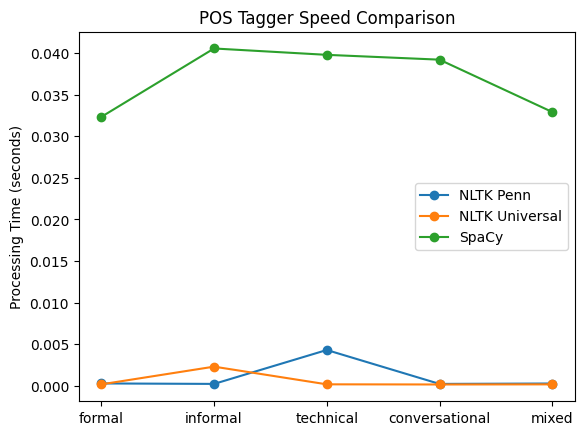

In [ ]:

import time
from collections import defaultdict

# Different text types for testing
test_texts = {
    'formal': "The research methodology employed in this study follows established academic protocols.",
    'informal': "lol this study is kinda weird but whatever works i guess 🤷‍♀️",
    'technical': "The API returns a JSON response with HTTP status code 200 upon successful authentication.",
    'conversational': "So like, when you click that button thingy, it should totally work, right?",
    'mixed': "OMG the algorithm's performance is absolutely terrible! The accuracy dropped to 23% wtf"
}

# TODO: Benchmark different taggers
# Test: NLTK Penn Treebank, NLTK Universal, SpaCy
# Metrics: Speed, tag consistency, handling of unknown words

benchmark_results = defaultdict(list)

for text_type, text in test_texts.items():
    print(f"\n🧪 Testing {text_type.upper()} text:")
    print(f"Text: {text}")
    print("-" * 60)

    # TODO: NLTK Penn Treebank timing
    start_time = time.time()
    nltk_penn_tags = nltk.pos_tag(tokens)
    nltk_penn_time = time.time() - start_time

    # TODO: NLTK Universal timing
    start_time = time.time()
    nltk_univ_tags = nltk.pos_tag(tokens, tagset='universal')
    nltk_univ_time = time.time() - start_time

    # TODO: SpaCy timing
    start_time = time.time()
    spacy_doc = nlp(text)
    spacy_time = time.time() - start_time

    # TODO: Count unknown/problematic tags
    nltk_unknown = sum(1 for _, tag in nltk_penn_tags if tag in ('FW', 'LS'))
    spacy_unknown = sum(1 for token in spacy_doc if token.pos_ == 'X')


    # Store results
    benchmark_results[text_type] = {
        'nltk_penn_time': nltk_penn_time,
        'nltk_univ_time': nltk_univ_time,
        'spacy_time': spacy_time,
        'nltk_unknown': nltk_unknown,
        'spacy_unknown': spacy_unknown
    }

    print(f"NLTK Penn time: {nltk_penn_time:.4f}s")
    print(f"NLTK Univ time: {nltk_univ_time:.4f}s")
    print(f"SpaCy time: {spacy_time:.4f}s")
    print(f"NLTK unknown words: {nltk_unknown}")
    print(f"SpaCy unknown words: {spacy_unknown}")

# TODO: Create performance comparison visualization
text_types = list(benchmark_results.keys())
nltk_penn_times = [benchmark_results[t]['nltk_penn_time'] for t in text_types]
nltk_univ_times = [benchmark_results[t]['nltk_univ_time'] for t in text_types]
spacy_times = [benchmark_results[t]['spacy_time'] for t in text_types]

x = range(len(text_types))

plt.figure()

plt.plot(x, nltk_penn_times, marker='o', label="NLTK Penn")
plt.plot(x, nltk_univ_times, marker='o', label="NLTK Universal")
plt.plot(x, spacy_times, marker='o', label="SpaCy")

plt.xticks(x, text_types)
plt.ylabel("Processing Time (seconds)")
plt.title("POS Tagger Speed Comparison")
plt.legend()

plt.show()




### 📊 Performance Analysis:
1. Which tagger is fastest? Does speed matter for your use case?
2. Which handles informal text best?
3. How do the taggers compare on technical jargon?
4. What trade-offs do you see between speed and accuracy?


1. NLTK is the fastest because it employs simpler statistical methods and more lightweight models. In systems that process massive amounts of text, speed is crucial.
2. SpaCy handles informal text best.
3. SpaCy typically performs better when processing slang, abbreviations, and colloquial expressions, as it possesses more advanced linguistic models and a larger vocabulary.
4. In practical applications, the choice depends on whether the scenario prioritizes real-time processing speed or places greater emphasis on higher accuracy and deeper language comprehension capabilities.


## 🚨 Lab Exercise 4: Edge Cases and Error Analysis (15 minutes)

Every system has limitations. Let's explore the edge cases where POS taggers struggle and understand why.


In [ ]:

# Challenging edge cases
edge_cases = [
    "Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.",  # Famous ambiguous sentence
    "Time flies like an arrow; fruit flies like a banana.",              # Classic ambiguity
    "The man the boat the river.",                                       # Garden path sentence
    "Police police Police police police police Police police.",          # Recursive structure
    "James while John had had had had had had had had had had had a better effect on the teacher.",  # Had had had...
    "Can can can can can can can can can can.",                         # Modal/noun ambiguity
    "@username #hashtag http://bit.ly/abc123 😂🔥💯",                   # Social media elements
    "COVID-19 AI/ML IoT APIs RESTful microservices",                    # Modern technical terms
]

print("🚨 EDGE CASE ANALYSIS")
print("=" * 50)

# TODO: Process each edge case and analyze failures
for i, text in enumerate(edge_cases, 1):
    print(f"\n🔍 Edge Case {i}:")
    print(f"Text: {text}")
    print("-" * 30)

    try:
        # TODO: Process with both taggers
        nltk_tags = nltk.pos_tag(nltk.word_tokenize(text))
        spacy_doc = nlp(text)

        # TODO: Identify potential errors or weird tags
        # Look for: repeated tags, unusual patterns, X tags, etc.

        print("NLTK tags:", [(w, t) for w, t in nltk_tags])
        print("SpaCy tags:", [(token.text, token.pos_) for token in spacy_doc])

        # TODO: Analyze what went wrong
        nltk_tag_counts = Counter(tag for _, tag in nltk_tags)
        spacy_tag_counts = Counter(tag for _, tag in spacy_tags)

        nltk_repeated = [tag for tag, count in nltk_tag_counts.items() if count > 3]
        spacy_repeated = [tag for tag, count in spacy_tag_counts.items() if count > 3]

        spacy_unknown = [token.text for token in spacy_doc if token.pos_ == "X"]

        print("\nAnalysis:")

        if nltk_repeated:
            print("NLTK repeated tags:", nltk_repeated)

        if spacy_repeated:
            print("SpaCy repeated tags:", spacy_repeated)

        if spacy_unknown:
            print("SpaCy unknown tokens:", spacy_unknown)

        if not nltk_repeated and not spacy_repeated and not spacy_unknown:
            print("No obvious tagging anomalies detected.")

    except Exception as e:
        print(f" Error processing: {e}")


    except Exception as e:
        print(f" Error processing: {e}")

# TODO: Reflection on limitations
print("\n🤔 REFLECTION ON LIMITATIONS:")
print("=" * 40)

print("""
POS taggers often struggle with highly ambiguous sentences and unusual language structures.
Examples like 'Buffalo buffalo...' or repeated words such as 'can can can...' confuse the models
because the same word can act as multiple parts of speech depending on context.

Garden-path sentences also cause problems because taggers typically analyze tokens locally
rather than understanding the full grammatical structure of the sentence.

Social media text introduces additional issues such as emojis, hashtags, and URLs, which
traditional taggers were not originally trained on. These tokens may be labeled as unknown
or assigned inconsistent tags.

Technical abbreviations like 'AI/ML' or 'RESTful' may also be tagged incorrectly because
they are uncommon in the training data used by many POS tagging models.
""")


🚨 EDGE CASE ANALYSIS

🔍 Edge Case 1:
Text: Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.
------------------------------
NLTK tags: [('Buffalo', 'NNP'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('.', '.')]
SpaCy tags: [('Buffalo', 'PROPN'), ('buffalo', 'NOUN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('.', 'PUNCT')]
 Error processing: name 'spacy_tags' is not defined

🔍 Edge Case 2:
Text: Time flies like an arrow; fruit flies like a banana.
------------------------------
NLTK tags: [('Time', 'NNP'), ('flies', 'NNS'), ('like', 'IN'), ('an', 'DT'), ('arrow', 'NN'), (';', ':'), ('fruit', 'CC'), ('flies', 'NNS'), ('like', 'IN'), ('a', 'DT'), ('banana', 'NN'), ('.', '.')]
SpaCy tags: [('Time', 'NOUN'), ('flies', 'VERB'), ('like', 'ADP'), ('an', 'DET'), ('arrow', 'NOUN'), (';', 'PUNCT'), ('f


### 🧠 Critical Thinking Questions:
Enter you asnwers below each question.
1. Why do these edge cases break the taggers?

2. How might you preprocess text to handle some of these issues?

3. When would these limitations matter in real applications?

4. How do modern large language models handle these cases differently?

---


1. Edge cases cause taggers to fail because many traditional POS taggers rely on training data and fixed rules, rendering them unable to recognize atypical text，such as slang, emojis, non-standard punctuation, spelling errors, or rare vocabulary.
2. Correct spelling errors; normalize repeated characters; remove or convert emojis and special characters; expand abbreviations and contractions; and standardize capitalization and punctuation usage.
3. If the tag of vocabulary is skewed, the system may be unable to accurately understand the user's intent or may misclassify information.
4. Modern large language models employ deep learning and contextual understanding mechanisms; trained on massive datasets, they are capable of grasping atypical linguistic patterns with greater depth. Consequently, they outperform traditional POS taggers in terms of accuracy.


## 🎯 Final Reflection and Submission

Congratulations! You've completed a comprehensive exploration of POS tagging, from basic concepts to real-world challenges.

### 📝 Reflection Questions (Answer in the cell below):

1. **Tool Comparison**: Based on your experience, when would you choose NLTK vs SpaCy? Consider factors like ease of use, accuracy, speed, and application type.

2. **Real-World Applications**: Describe a specific business problem where POS tagging would be valuable. How would you implement it?

3. **Limitations and Solutions**: What are the biggest limitations you discovered? How might you work around them?

4. **Future Learning**: What aspects of POS tagging would you like to explore further? (Neural approaches, custom training, domain adaptation, etc.)

5. **Integration**: How does POS tagging fit into larger NLP pipelines? What other NLP tasks might benefit from POS information?



### ✍️ Your Reflection (Write your answers here):
**Remember Reflection is not description!**

**1. Tool Comparison:**
Their application depends on the specific task. When building small-scale research projects, I would choose NLTK due to its simplicity and flexibility; however, when handling large-scale, real-world applications, I would opt for SpaCy, as it offers higher accuracy and enables high-speed processing of massive text datasets.

**2. Real-World Applications:**
A practical business application scenario for POS tagging is the analysis of customer feedback. Companies can leverage POS tagging technology to identify keywords describing specific issues. Then, the system can automatically categorize various complaints and route them to the appropriate functional departments for resolution.

**3. Limitations and Solutions:**
The biggest limitations facing POS tagging include the difficulty in handling informal language, internet slang, spelling errors, ambiguous vocabulary, and specialized terminology. To mitigate these issues, we can preprocess the text，clean noisy data， and expand abbreviations，to enhance tagging accuracy.

**4. Future Learning:**
I would like to explore the field of domain adaptation, learning how training models on specialized datasets within specific domains enhances the performance of POS tagging in industries such as healthcare, finance, or technology.

**5. Integration:**
POS tagging is typically an early step in the NLP processing pipeline. It provides syntactic information that helps subsequent tasks understand the structure of a sentence. Other NLP tasks that benefit from POS tagging include Text Classification, Named Entity Recognition, Sentiment Analysis, and etc.



---

## 📤 Submission Checklist

Before submitting your completed notebook, make sure you have:

- [ ] ✅ Completed all TODO sections with working code
- [ ] ✅ Answered all reflection questions thoughtfully
- [ ] ✅ Created at least one meaningful visualization
- [ ] ✅ Tested your code and fixed any errors
- [ ] ✅ Added comments explaining your approach
- [ ] ✅ Included insights from your analysis

### 📋 Submission Instructions:
1. **Save your notebook**: File → Save (or Ctrl+S)
2. **Download**: File → Download → Download .ipynb
3. **Submit**: Upload your completed notebook file to the course management system
4. **Filename**: Use format: `L05_LastName_FirstName_ITAI2373.ipynb or pdf`  

### 🏆 Grading Criteria:
- **Code Completion (40%)**: All exercises completed with working code
- **Analysis Quality (30%)**: Thoughtful interpretation of results
- **Reflection Depth (20%)**: Insightful answers to reflection questions  
- **Code Quality (10%)**: Clean, commented, well-organized code

---

## 🎉 Great Work!

You've successfully explored the fascinating world of POS tagging! You now understand how computers parse human language and can apply these techniques to solve real-world problems.


Keep exploring and happy coding! 🚀
